# <img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 8

Autor: Lopez Cruz Juan Carlos.

# Introducción

1. Sea la función Inmitancia:

$$F(s) = \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)}$$

Se pide hallar la topología circuital y los valores de los componentes:

a) Síntesis de $Z(s)$ mediante el método de Foster en su versión serie  
b) Síntesis de $Y(s)$ mediante el método de Foster en su versión derivación  
c) Síntesis de $Z(s)$ mediante el método de Cauer remoción en infinito  
d) Síntesis de $Z(s)$ mediante el método de Cauer remoción en DC  
e) Simular $Z(s)$ en LTSpice, observando los cambios de fase y la ley de variación (pendiente) de la Impedancia total de la red.  

# <img src="simulacion_LTSpice.png" /> 

2. Sea la siguiente red, pensándolo como una Inmitancia $F_{12}$:

a) Hallar el valor de los componentes sabiendo que satisface la función admitancia propuesta:

$$Y(s) = \frac{s^5 + 18s^3 + 48s}{6s^4 + 42s^2 + 48}$$

# <img src="red_punto2_ts8.png" /> 

3. Encuentre el valor de los elementos que integran el siguiente circuito y que satisface la función impedancia propuesta:

# <img src="red_punto3_ts8.png" /> 

$$Z(s) = \frac{s^2 + 6s + 8}{s^2 + 6s + 5}$$


### Bonus

* Implementar en Python el punto 1 verificando los resultados usando las funciones de pytc2:  
  *dibujar_foster_serie* ; *dibujar_foster_derivacion* ; *dibujar_cauer_LC*;
* Simulación circuital del punto 2. Medir la admitancia y explicar comportamiento en DC.

### Modulos Python

In [24]:
import sympy as sp
from pytc2.sintesis_dipolo import foster, cauer_LC 
from pytc2.dibujar import dibujar_foster_serie, dibujar_foster_derivacion, dibujar_cauer_LC
from pytc2.general import s, a_equal_b_latex_s, print_latex
from pytc2.remociones import remover_polo_infinito, remover_polo_dc

import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal

s = sp.symbols('s ', complex=True)

In [12]:
def graficar_polos_ceros_1D(num, den, nombre_funcion="Z(s)", x_lim_max=3.0):
    """
    Grafica el diagrama 1D de polos y ceros en el eje jw para funciones LC.
    Mantiene una escala fija (x_lim_max) para que todos los gráficos queden alineados.
    """
    # Obtenemos polos y ceros
    sys = signal.TransferFunction(num, den)
    zeros_complex = sys.zeros
    poles_complex = sys.poles

    # Frecuencias en el eje jw (omega = |imag|)
    ceros_w = np.unique(np.abs(np.imag(zeros_complex)))
    polos_w = np.unique(np.abs(np.imag(poles_complex)))

    # Análisis del comportamiento en s -> inf
    grado_num = len(num) - 1
    grado_den = len(den) - 1
    
    polo_en_infinito = grado_num > grado_den
    cero_en_infinito = grado_den > grado_num

    # Construcción de etiquetas dinámicas
    etiquetas = {}
    todas_las_w = np.sort(np.unique(np.concatenate([ceros_w, polos_w])))

    for w in todas_las_w:
        if np.isclose(w, 0):
            etiquetas[0] = "$0$"
        elif np.isclose(w, np.round(w)):
            etiquetas[w] = f"${int(np.round(w))}$"
        else:
            w_sq = w**2
            frac_num = int(np.round(w_sq * 3))
            if np.isclose(w_sq * 3, frac_num) and frac_num % 3 != 0:
                etiquetas[w] = rf"$\sqrt{{\frac{{{frac_num}}}{{3}}}}$"
            else:
                etiquetas[w] = rf"$\sqrt{{{int(np.round(w_sq))}}}$"

    # Graficación
    plt.figure(figsize=(9, 2.5))
    ax = plt.gca()

    # Eje jw
    plt.axhline(0, color='black', linewidth=1.5)

    # Dibujar ceros ('o' azul) y polos ('x' rojo)
    plt.scatter(ceros_w, [0]*len(ceros_w), color='tab:blue', marker='o', s=120, 
                facecolors='none', edgecolors='tab:blue', linewidth=2, zorder=3)
    plt.scatter(polos_w, [0]*len(polos_w), color='crimson', marker='x', s=120, 
                linewidth=2.5, zorder=3)

    # *** POSICIÓN ESCALA FIJA PARA MBOJOJA (ALINEAR) ***
    x_inf = x_lim_max  # Posición fija para el infinito en todos los gráficos

    # Representación adecuada en el infinito
    if polo_en_infinito:
        plt.text(x_inf, 0, r") x", color='crimson', fontsize=16, fontweight='bold', va='center', ha='center')
    elif cero_en_infinito:
        plt.text(x_inf, 0, r") o", color='tab:blue', fontsize=16, fontweight='bold', va='center', ha='center')

    # Flecha final y etiqueta jw
    plt.annotate('', xy=(x_inf + 0.5, 0), xytext=(x_inf + 0.1, 0),
                 arrowprops=dict(arrowstyle="->", color='black', lw=1.5))
    plt.text(x_inf + 0.5, -0.2, r'$j\omega$', fontsize=14, ha='center')

    # Configuración de ejes y etiquetas
    plt.xticks(list(etiquetas.keys()), list(etiquetas.values()), fontsize=13)
    plt.text(-0.6, 0.15, rf'${nombre_funcion}$', fontsize=14, va='center', fontweight='bold')

    # *** LÍMITES DEL EJE X FIJOS ***
    plt.yticks([]) 
    plt.xlim(-0.8, x_inf + 0.8)  # Mantener siempre el mismo ancho de eje
    plt.ylim(-0.5, 0.5)
    plt.grid(True, which='both', linestyle=':', alpha=0.6)

    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

## Resolucion

### Función a desarrollar

$$F(s) = \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)}$$

#### Síntesis mediante Foster Serie $Z(s)$

$$F(s) = Z(s) = \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)} = \frac{(s^2 + 1) \cdot (s^2 + 3)}{s \cdot (s^2 + 2)}$$

Expresaremos nuestra funcion impedancia $Z(s)$ como lasuma de terminos que correspoden a los componentes electricos en seria del desarrolo de foster en serie (capacitores, inductores y tanques $LC$ en paralelo).

$$Z(s) = k_\infty \cdot s + \frac{k_0}{s} + \sum \frac{2 k_i s}{s^2 + \omega_i^2}$$

donde:
* $k_\infty \cdot s$ representa un inductor en serie de valor $L = k_\infty$.
* $\frac{k_0}{s}$ representa un capacitor en serie de valor $C = \frac{1}{k_0}$.
* $\frac{2 k_i s}{s^2 + \omega_i^2}$ representa un tanque $LC$ paralelo conectado en serie con los demás componentes.

Primero procedemos a visualizar los polos y ceros de nuestra funcion impedancia $Z(s)$

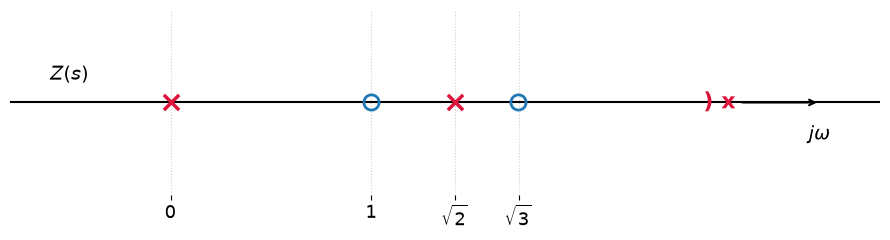

In [3]:
num = [1, 0, 4, 0, 3]
den = [1, 0, 2, 0]

graficar_polos_ceros_1D(num, den, nombre_funcion="Z(s)")

Podemos observar que para esta funcion transferencia tenemos polos en el origen y en infinito, por lo que tendremos los componentes electricos correspondientes a cada residuo.

**Cálculo del residuo en el infinito ($k_\infty$)**

Procedemos a evaluar el comportamiento de nuestra funcion impedancia $Z(s)$ a frecuencia infinitas ($\omega \to \infty$) para determinar si existe un comportamiento inductivo directo en serie

$$k_\infty = \lim_{s \to \infty} \frac{1}{s} Z(s) = \lim_{s \to \infty} \frac{1}{s} \cdot \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)} = 1$$

* *Resultado:* $k_\infty = 1 \longrightarrow L_\infty = 1 $ *(Inductancia en serie)*.

**Cálculo del residuo en el origen ($k_0$)**

Procedemos a evaluar el comportamiento de nuestra funcion impedancia $Z(s)$ a frecuencia cero ($s \to 0$ o DC) para aislar la presencia de un polo en el origen, el cual representa un capacitor en serie.

$$k_0 = \lim_{s \to 0} s \cdot Z(s) = \lim_{s \to 0} s \cdot \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)} = \frac{3}{2}$$

* *Resultado:* $k_0 = \frac{3}{2} \longrightarrow \frac{1}{k_0} = \frac{2}{3} $ *(Capacidad en serie)*.

**Cálculo de los residuos en los polos sobre el eje imaginario ($2k_1$)**

Procedemos a analizar los polos finitos en $s^2 = -2$ (donde $\omega_1^2 = 2$) mediante la técnica del residuo, que dará lugar a los bloques resonantes ($LC$ paralelo).

$$2 k_1 = \lim_{s^2 \to -2} \frac{s^2 + 2}{s} Z(s) = \lim_{s^2 \to -2} \frac{s^2 + 2}{s} \cdot \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)}$$

$$2 k_1 = \lim_{s^2 \to -2} \frac{s^4 + 4s^2 + 3}{s^2} = \frac{(-2)^2 + 4(-2) + 3}{-2} = \frac{4 - 8 + 3}{-2} = \frac{-1}{-2} = \frac{1}{2}$$

* *Resultado:* $2 k_1 = \frac{1}{2}$.

**Deducción y cálculo de los componentes del tanque paralelo ($LC$)**

Procedemos a igualar la expresión teórica de la impedancia de un tanque $LC$ paralelo con el término obtenido en la expansión ($2k_1$) para obtener las fórmulas de $C$ y $L$. 

La impedancia de una bobina en paralelo con un capacitor es:

$$Z_{tanque}(s) = \frac{\frac{1}{sC} \cdot sL}{\frac{1}{sC} + sL} = \frac{sL}{s^2 LC + 1} = \frac{\frac{1}{C} \cdot s}{s^2 + \frac{1}{LC}}$$

Igualando con la forma general $\frac{2k_i \cdot s}{s^2 + \omega_i^2}$:
$$\begin{cases} 
2k_i = \frac{1}{C} &\longrightarrow C = \frac{1}{2k_1} \\ 
\omega_i^2 = \frac{1}{LC} &\longrightarrow L = \frac{2k_i}{\omega_i^2} 
\end{cases}$$

Reemplazando los valores obtenidos ($2k_1 = \frac{1}{2}$ y $\omega_1^2 = 2$):

* *Capacitor del tanque:* $C_1 = \frac{1}{2k_1} = \frac{1}{1/2} = 2 $
* *Inductor del tanque:* $L_1 = \frac{2k_1}{\omega_1^2} = \frac{1/2}{2} = \frac{1}{4} $

#### Síntesis del Circuito Final (Valores de los componentes)

Agrupamos la totalidad de los elementos en seria segun el esquema de Foster.

* **Capacitor en serie inicial ($C_0$):** $\frac{1}{k_0} = \frac{2}{3} $
* **Inductor en serie ($L_\infty$):** $k_\infty = 1 $
* **Tanque $LC$ paralelo en serie:**
   * Capacitor en paralelo: $C_1 = 2 $
   * Inductor en paralelo: $L_1 = \frac{1}{4} $

#### Verificacion de los componentes

Procedemos a verificar los componentes obtenidos mediante python.

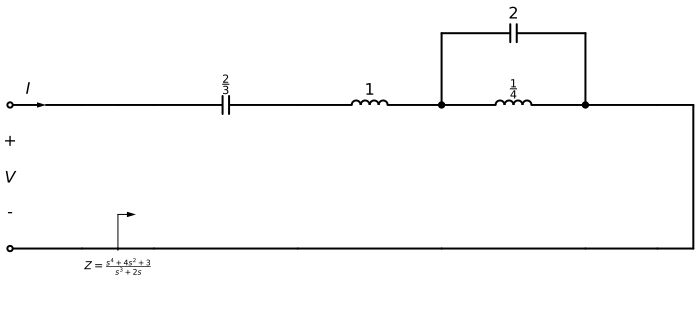

In [4]:
# Sea la siguiente función de excitación
FF = ( s**4 + 4*s**2 + 3)/( s**3 + 2*s)
# Se expande FF a la Foster
k0, koo, ki_wi, _, FF_foster = foster(FF)
# Tratamos a nuestra función imitancia como una Zderivacion
dibujar_foster_serie(k0 = k0, koo = koo, ki = ki_wi, z_exc = FF)

### Síntesis mediante Foster Derivación $Y(s)$

Para este caso realizaremos **dos análisis distintos** según la interpretación de la función inmitancia dada $F(s)$:

#### Análisis 1: Sintetizar $Y(s) = \frac{1}{Z(s)}$ (Inversa de la impedancia del anterior analisis)

Si consideramos que la función dada originalmente era la impedancia $Z(s) = \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)}$, la admitancia a sintetizar es su recíproca:

$$Y(s) = \frac{1}{Z(s)} = \frac{s(s^2 + 2)}{s^4 + 4s^2 + 3}$$

$$Y(s) = \frac{s(s^2 + 2)}{(s^2 + 1)(s^2 + 3)}$$

Forma general de la expansión en fracciones simples para Foster Derivación:
$$Y(s) = k_\infty \cdot s + \frac{k_0}{s} + \sum \frac{2 k_i s}{s^2 + \omega_i^2}$$

Procedemos a graficar los polos y ceros de nuestra $Y(s)$

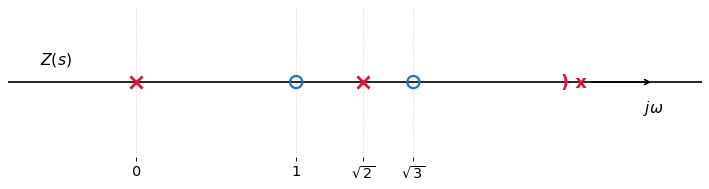

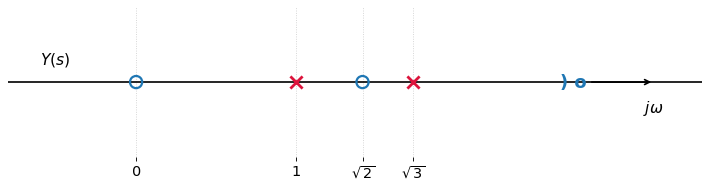

In [29]:
graficar_polos_ceros_1D(num, den, nombre_funcion="Z(s)")
graficar_polos_ceros_1D(den, num, nombre_funcion="Y(s)")

Podemos visualizar como se alterna los polos y ceros cuando pasamos de $Z(s)$ a $Y(s) = \frac{1}{Z(s)}$, donde ya no tendremos polos en infinito y en el origen, descartando los primeros componentes en derivacion. 

**Cálculo de los residuos en los polos sobre el eje imaginario ($2k_1$ y $2k_2$)**

La admitancia presenta dos pares de polos conjugados sobre el eje $j\omega$:
* Primer polo en $s^2 = -1 $
* Segundo polo en $s^2 = -3 $

* *Para $s^2 = -1$:*
$$2 k_1 = \lim_{s^2 \to -1} \frac{s^2 + 1}{s} Y(s) = \lim_{s^2 \to -1} \frac{s^2 + 2}{s^2 + 3} = \frac{-1 + 2}{-1 + 3} = \frac{1}{2}$$

* *Para $s^2 = -3$:*
$$2 k_2 = \lim_{s^2 \to -3} \frac{s^2 + 3}{s} Y(s) = \lim_{s^2 \to -3} \frac{s^2 + 2}{s^2 + 1} = \frac{-3 + 2}{-3 + 1} = \frac{1}{2}$$

**Deducción de los componentes para cada rama $LC$ serie en derivación**

Para una rama compuesta por una bobina y un capacitor en serie conectados en paralelo a la red:
$$Y_{rama}(s) = \frac{\frac{1}{sL} \cdot sC}{\frac{1}{sL} + sC} = \frac{\frac{C}{L}}{\frac{sLC + 1}{sL}} = \frac{sC}{sLC + 1} =\frac{\frac{1}{L} \cdot s}{s^2 + \frac{1}{LC}} \implies 2k_i = \frac{1}{L} \quad \text{y} \quad \omega_i^2 = \frac{1}{LC}$$

* *Rama 1 ($\omega_1^2 = 1, 2k_1 = 1/2$):*
  * *Inductor:* $L_1 = \frac{1}{2k_1} = 2$
  * *Capacitor:* $C_1 = \frac{2k_1}{\omega_1^2} = \frac{1/2}{1} = \frac{1}{2}$

* *Rama 2 ($\omega_2^2 = 3, 2k_2 = 1/2$):*
  * *Inductor:* $L_2 = \frac{1}{2k_2} = 2$
  * *Capacitor:* $C_2 = \frac{2k_2}{\omega_2^2} = \frac{1/2}{3} = \frac{1}{6}$

* **Resultado Análisis 1:** Circuito compuesto por **2 ramas $LC$ serie en paralelo**.

#### Verificacion de los componentes

Procedemos a verificar los componentes obtenidos mediante python.

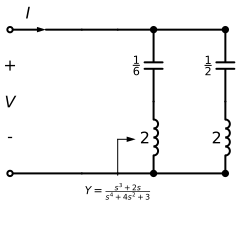

In [5]:
# Sea la siguiente función de excitación
FF = (s**4 + 4*s**2 + 3)/(s**3 + 2*s)
# Se expande FF a la Foster
k0, koo, ki, _, FF_foster = foster(1/FF)

# Tratamos a nuestra función imitancia como una Y
dibujar_foster_derivacion(k0 = k0, koo = koo , ki = ki , y_exc = 1/FF)

#### Análisis 2: Sintetizar tomando $Y(s) = F(s)$ directamente

Si interpretamos que la función inmitancia dada en el enunciado $F(s)$ es directamente la función admitancia de la red:

$$Y(s) = F(s) = \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)}$$

Forma general de la expansión en fracciones simples para Foster Derivación:
$$Y(s) = k_\infty \cdot s + \frac{k_0}{s} + \sum \frac{2 k_i s}{s^2 + \omega_i^2}$$

Podemos notar que nuestro polos y ceros seran iguales al analisis de $Z(s)$

**Cálculo del residuo en el infinito ($k_\infty$)**

Procedemos a evaluar el comportamiento de $Y(s)$ a frecuencias infinitas ($\omega \to \infty$) para determinar si existe un comportamiento capacitivo directo en derivación.

$$k_\infty = \lim_{s \to \infty} \frac{1}{s} Y(s) = \lim_{s \to \infty} \frac{1}{s} \cdot \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)} = 1$$

* *Resultado:* $k_\infty = 1 \longrightarrow C_\infty = 1$ *(Capacitor en derivación)*.

**Cálculo del residuo en el origen ($k_0$)**

Procedemos a evaluar el comportamiento de $Y(s)$ a frecuencia cero ($s \to 0$ o DC) para aislar la presencia de un polo en el origen, el cual representa un inductor en derivación.

$$k_0 = \lim_{s \to 0} s \cdot Y(s) = \lim_{s \to 0} s \cdot \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)} = \frac{3}{2}$$

* *Resultado:* $k_0 = \frac{3}{2} \longrightarrow L_0 = \frac{1}{k_0} = \frac{2}{3}$ *(Inductor en derivación)*.

**Cálculo del residuo en los polos sobre el eje imaginario ($2k_1$)**

Analizamos el par de polos en $s^2 = -2 \implies \omega_1^2 = 2$:

$$2 k_1 = \lim_{s^2 \to -2} \frac{s^2 + 2}{s} Y(s) = \lim_{s^2 \to -2} \frac{s^4 + 4s^2 + 3}{s^2} = \frac{(-2)^2 + 4(-2) + 3}{-2} = \frac{1}{2}$$

* *Resultado:* $2 k_1 = \frac{1}{2}$.

**Deducción de los componentes para la rama $LC$ serie en derivación**

Para la rama $LC$ serie caracterizada por $2k_1 = \frac{1}{2}$ y $\omega_1^2 = 2$:

$$\begin{cases} 
L_1 = \frac{1}{2k_1} = \frac{1}{\frac{1}{2}} = 2 \\ 
C_1 = \frac{2k_1}{\omega_1^2} = \frac{\frac{1}{2}}{2} = \frac{1}{4} 
\end{cases}$$

#### Síntesis del Circuito Final

* *Resultado del análisis 2 ($Y(s) = F(s)$):*
  * *Capacitor en derivación ($C_\infty$):* $C = 1$
  * *Inductor en derivación ($L_0$):* $L = \frac{2}{3}$
  * *Rama $LC$ serie en derivación:* $L_1 = 2 \quad , \quad C_1 = \frac{1}{4}$

#### Verificacion

Procedemos a verificar nuestros componentes calculados.

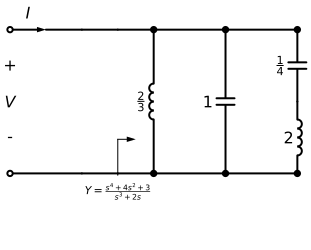

In [3]:
# Sea la siguiente función de excitación
FF = (s**4 + 4*s**2 + 3)/(s**3 + 2*s)
# Se expande FF a la Foster
k0, koo, ki, _, FF_foster = foster(FF)

# Tratamos a nuestra función imitancia como una Y
dibujar_foster_derivacion(k0 = k0, koo = koo , ki = ki , y_exc = FF)

### Síntesis mediante Cauer (Remoción en el Infinito)

**Función de Inmitancia dada:**
$$F(s) = Z(s) = \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)} = \frac{s^4 + 4s^2 + 3}{s^3 + 2s}$$

#### Fundamento del Método de Cauer I (Remoción en $\infty$)

El método de Cauer realiza divisiones sucesivas ordenando los polinomios del numerador y denominador en **potencias decrecientes de $s$**. 

* Como comenzamos dividiendo una impedancia $Z(s)$, el primer cociente obtenido representa un **inductor en serie** ($L \cdot s$).
* El residuo se invierte para transformarlo en una admitancia $Y(s)$, por lo que el siguiente cociente representa un **capacitor en derivación** ($C \cdot s$).
* Se repite el proceso alternando divisiones para obtener una red en escalera (tipo *L-section*).

**Primera División (Extracción de $L_1$)**

Dividimos los polinomios ordenados para extraer el primer término inductivo en serie:

$$
\begin{array}{r|l}
s^4 + 4s^2 + 3 & s^3 + 2s \\
\hline & \mathbf{1s} \\
s^4 + 4s^2 + 3 \\
-(s^4 + 2s^2) \phantom{+ 3} \\
\hline
\mathbf{2s^2 + 3} & 
\end{array}
$$

El cociente $1s$ indica un inductor en serie de valor $L_1 = 1$.


**Segunda División (Extracción de $C_1$)**

Invertimos la función (pasamos a admitancia) dividiendo el denominador anterior entre el nuevo resto:

$$
\begin{array}{r|l}
s^3 + 2s & 2s^2 + 3 \\
\hline & \mathbf{\frac{1}{2}s} \\
s^3 + 2s \\
-(s^3 + \frac{3}{2}s) \\
\hline
\mathbf{\frac{1}{2}s} & 
\end{array}
$$

El cociente $\frac{1}{2}s$ representa un capacitor conectado en derivación a masa de valor $C_1 = \frac{1}{2}$.

**Tercera División (Extracción de $L_2$)**

Invertimos nuevamente la función (pasamos a impedancia) dividiendo el divisor previo entre el resto:

$$
\begin{array}{r|l}
2s^2 + 3 & \frac{1}{2}s \\
\hline & \mathbf{4s} \\
2s^2 + 3 \\
-(2s^2) \phantom{+ 3} \\
\hline
\mathbf{3} & 
\end{array}
$$

El cociente $4s$ representa un segundo inductor conectado en serie de valor $L_2 = 4$.

**Cuarta División (Extracción de $C_2$)**

Dividimos el resto anterior entre la constante sobrante para cancelar completamente la función:

$$
\begin{array}{r|l}
\frac{1}{2}s & 3 \\
\hline & \mathbf{\frac{1}{6}s}\\
\frac{1}{2}s \\
-(\frac{1}{2}s) \\
\hline
\mathbf{0} & 
\end{array}
$$

El cociente final $\frac{1}{6}s$ nos da el valor del último capacitor en derivación $C_2 = \frac{1}{6}$. Al ser el resto $0$, la síntesis queda completada.

#### Valores de los componentes obtenidos

1. **$L_1 = 1$** (Inductor en rama serie inicial)
2. **$C_1 = \frac{1}{2}$** (Capacitor en rama derivación)
3. **$L_2 = 4$** (Inductor en rama serie)
4. **$C_2 = \frac{1}{6}$** (Capacitor en rama derivación final)

### Visualizacion de los polos y ceros ante las remociones.

Procedemos a ver como ocurren la remociones usando python, donde las impedancias/admitancias impares son los componentes removidos 

In [19]:
# Sea la siguiente función de excitación
Z = (s**4 + 4*s**2 + 3)/(s**3 + 2*s)

print_latex(a_equal_b_latex_s('Z(s)', Z))

inmitancias = [("Z(s)", Z)]
inmitancia_actual = Z

for i in range(1, 5):
    prefijo = "Z" if i % 2 != 0 else "Y"
    prefijo_inverso = "Y" if i % 2 != 0 else "Z"
    
    # 1. Remoción en infinito
    remanente, removido = remover_polo_infinito(inmitancia_actual)
    
    # 2. Imprimir en LaTeX
    print_latex(a_equal_b_latex_s(f'{prefijo}_{{{2*i-1}}}(s)', removido))
    print_latex(a_equal_b_latex_s(f'{prefijo}_{{{2*i}}}(s)', remanente))
    
    if remanente != 0:
        # Guardar la inmitancia remanente
        nombre_remanente = f"{prefijo}_{{{2*i}}}(s)"
        inmitancias.append((nombre_remanente, remanente))
        
        # Calcular y guardar la inmitancia inversa (para ver la inversión de polos/ceros)
        inversa = 1 / remanente
        nombre_inversa = f"{prefijo_inverso}_{{{2*i}}}(s)"
        inmitancias.append((nombre_inversa, inversa))
        
        # Preparar la inmitancia para la siguiente iteración
        inmitancia_actual = inversa

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Como podemos observar en la remociones (impedancias/admitancias impares) encontramos los valores de los componentes que se remueven, ahora veremos como se representan dichas remociones a la impedancia/admitancia resultante.

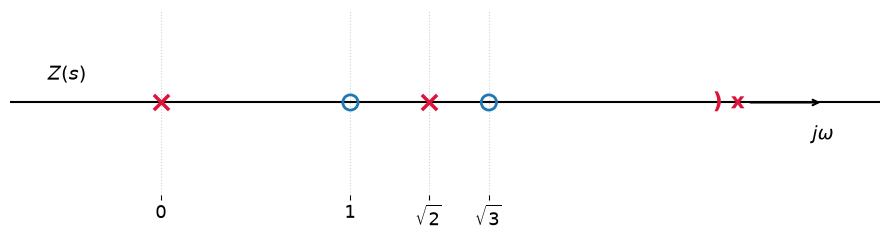

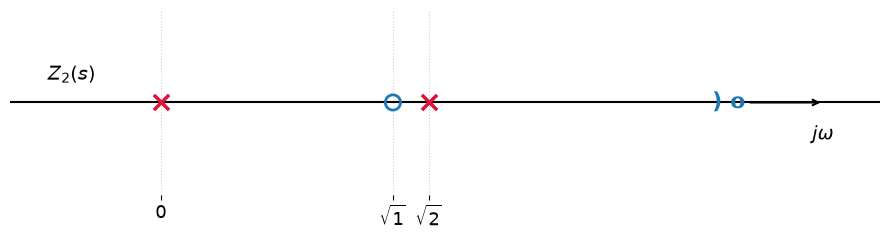

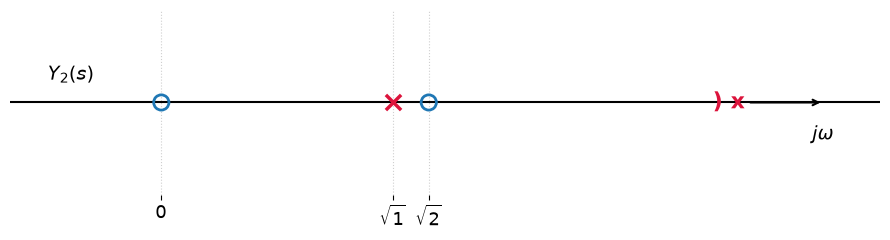

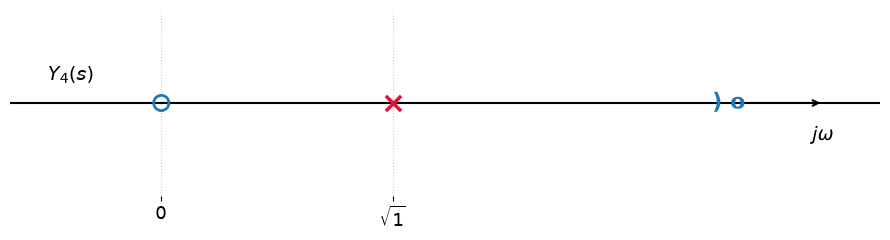

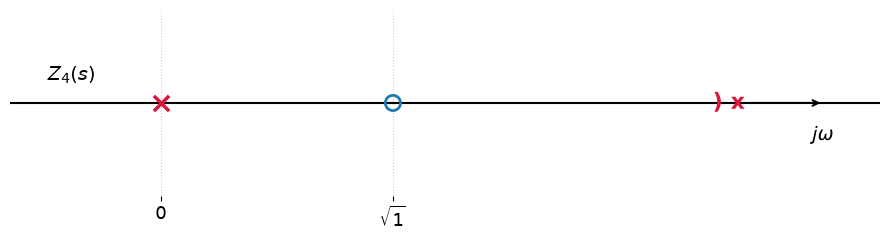

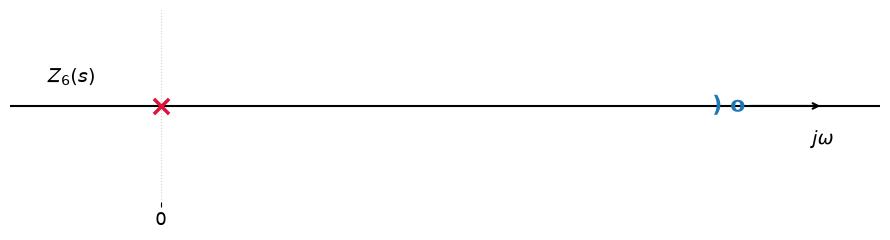

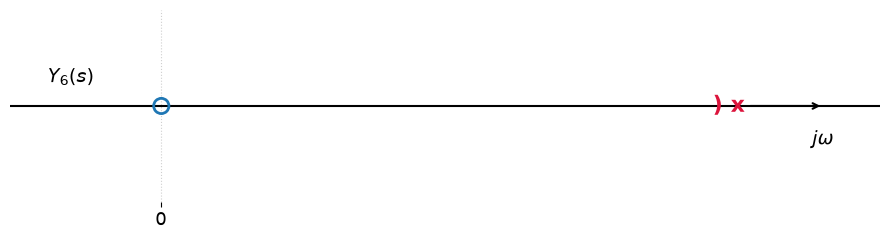

In [22]:
for nombre, expr in inmitancias:
    # 1. Expandir y simplificar
    expr_simp = sp.cancel(sp.expand(expr))
    num_sp, den_sp = sp.fraction(expr_simp)
    
    # 2. Convertir a polinomios de SymPy asegurando la variable 's'
    # Usamos Poly.from_expr o convertimos con sp.Poly asegurando expand
    num_poly = sp.Poly(sp.expand(num_sp), s)
    den_poly = sp.Poly(sp.expand(den_sp), s)
    
    # 3. Extraer coeficientes flotantes
    num_coeffs = [float(c) for c in num_poly.all_coeffs()]
    den_coeffs = [float(c) for c in den_poly.all_coeffs()]
    
    # 4. Graficar
    graficar_polos_ceros_1D(num_coeffs, den_coeffs, nombre_funcion=nombre)

Como podemos obesrvar los ceros se desplazan hacia la derecha, donde el cero que esta antes del polo en infinito al realizar la remocion este pasa a ocupar su lugar, siendo de esta manera que si removemos en impedancia ($Z(s)$) lo que se pone en cauer es un componente en serie, y al realizar un remocion en admitancia ($Y(s)$) lo que se pone en cauer es un componente en derivacion.

### Verificacion

Procedemos a verificar nuestros componentes hallados.

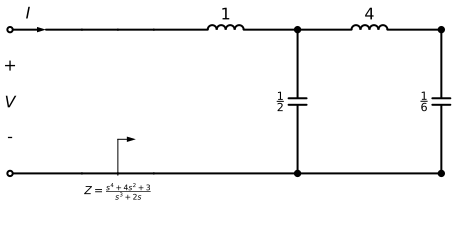

In [4]:
# Sea la siguiente función de excitación
FF = (s**4 + 4*s**2 + 3)/(s**3 + 2*s)

# Implementaremos FF mediante Cauer 1 o remociones continuas en infinito
koo, F_cauer_oo, rem = cauer_LC(FF, remover_en_inf=True)

# Tratamos a nuestra función inmitancia como una Z
dibujar_cauer_LC(koo, z_exc = FF)

### Síntesis mediante Cauer (Remoción en DC)

**Función de Inmitancia dada:**
$$F(s) = Z(s) = \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)} = \frac{3 + 4s^2 + s^4}{2s + s^3}$$

#### Método de Cauer II (Remoción en $s = 0$)

El método de Cauer II realiza divisiones sucesivas ordenando los polinomios del numerador y denominador en **potencias crecientes de $s$**. 

* Como comenzamos dividiendo una impedancia $Z(s)$, el primer cociente obtenido representa un **capacitor en serie** ($\frac{k}{s}$ con valor $C = \frac{1}{k}$).
* El residuo se invierte para transformarlo en una admitancia $Y(s)$, por lo que el siguiente cociente representa un **inductor en derivación** ($\frac{k}{s}$ con valor $L = \frac{1}{k}$).
* Se repite el proceso alternando divisiones para obtener una red en escalera (tipo *L-section*).

**Primera División (Extracción de $C_1$)**

Dividimos los polinomios ordenados en potencias crecientes para extraer el primer término capacitivo en serie:

$$
\begin{array}{r|l}
3 + 4s^2 + s^4 & 2s + s^3 \\
\hline & \mathbf{\frac{3}{2s}} \\
3 + 4s^2 + s^4 \\
-(3 + \frac{3}{2}s^2) \phantom{+ s^4} \\
\hline
\mathbf{\frac{5}{2}s^2 + s^4} & 
\end{array}
$$

El cociente $\frac{\frac{3}{2}}{s}$ indica un capacitor en serie de valor $C_1 = \frac{1}{\frac{3}{2}} = \frac{2}{3}$.

**Segunda División (Extracción de $L_1$)**

Invertimos la función (pasamos a admitancia) dividiendo el denominador anterior entre el nuevo resto:

$$
\begin{array}{r|l}
2s + s^3 & \frac{5}{2}s^2 + s^4 \\
\hline & \mathbf{\frac{4}{5s}} \\
2s + s^3 \\
-(2s + \frac{4}{5}s^3) \\
\hline
\mathbf{\frac{1}{5}s^3} & 
\end{array}
$$

El cociente $\frac{\frac{4}{5}}{s}$ representa un inductor conectado en derivación a masa de valor $L_1 = \frac{1}{\frac{4}{5}} = \frac{5}{4}$.

**Tercera División (Extracción de $C_2$)**

Invertimos nuevamente la función (pasamos a impedancia) dividiendo el divisor previo entre el resto:

$$
\begin{array}{r|l}
\frac{5}{2}s^2 + s^4 & \frac{1}{5}s^3 \\
\hline & \mathbf{\frac{25}{2s}} \\
\frac{5}{2}s^2 + s^4 \\
-(\frac{5}{2}s^2) \phantom{+ s^4} \\
\hline
\mathbf{s^4} & 
\end{array}
$$

El cociente $\frac{\frac{25}{2}}{s}$ representa un segundo capacitor conectado en serie de valor $C_2 = \frac{1}{\frac{25}{2}} = \frac{2}{25}$.

**Cuarta División (Extracción de $L_2$)**

Dividimos el resto anterior entre la potencia sobrante para cancelar completamente la función:

$$
\begin{array}{r|l}
\frac{1}{5}s^3 & s^4 \\
\hline & \mathbf{\frac{1}{5s}} \\
\frac{1}{5}s^3 \\
-(\frac{1}{5}s^3) \\
\hline
\mathbf{0} & 
\end{array}
$$

El cociente final $\frac{\frac{1}{5}}{s}$ nos da el valor del último inductor en derivación $L_2 = \frac{1}{\frac{1}{5}} = 5$. Al ser el resto $0$, la síntesis queda completada.

#### Valores de los componentes obtenidos

1. **$C_1 = \frac{2}{3}$** (Capacitor en rama serie inicial)
2. **$L_1 = \frac{5}{4}$** (Inductor en rama derivación)
3. **$C_2 = \frac{2}{25}$** (Capacitor en rama serie)
4. **$L_2 = 5$** (Inductor en rama derivación final)

### Visualizacion de los polos y ceros ante las remociones.

Procedemos a ver como ocurren la remociones usando python, donde las impedancias/admitancias impares son los componentes removidos 

In [25]:
# Función de excitación inicial
Z = (s**4 + 4*s**2 + 3) / (s**3 + 2*s)

inmitancias = [("Z(s)", Z)]
inmitancia_actual = Z

for i in range(1, 5):
    prefijo = "Z" if i % 2 != 0 else "Y"
    prefijo_inverso = "Y" if i % 2 != 0 else "Z"
    
    # 1. Remoción total en DC (s = 0)
    remanente, removido = remover_polo_dc(inmitancia_actual)
    
    # 2. Mostrar resultados en LaTeX
    print_latex(a_equal_b_latex_s(f'{prefijo}_{{{2*i-1}}}(s)', removido))
    print_latex(a_equal_b_latex_s(f'{prefijo}_{{{2*i}}}(s)', remanente))
    
    if remanente != 0:
        # Guardar la inmitancia remanente
        nombre_remanente = f"{prefijo}_{{{2*i}}}(s)"
        inmitancias.append((nombre_remanente, remanente))
        
        # Calcular y guardar la inversa para visualizar la conversión polo <-> cero
        inversa = sp.cancel(sp.expand(1 / remanente))
        nombre_inversa = f"{prefijo_inverso}_{{{2*i}}}(s)"
        inmitancias.append((nombre_inversa, inversa))
        
        # Preparar la inmitancia inversa para el siguiente ciclo
        inmitancia_actual = inversa

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Como podemos observar en la remociones (impedancias/admitancias impares) encontramos los valores de los componentes que se remueven, ahora veremos como se representan dichas remociones a la impedancia/admitancia resultante.

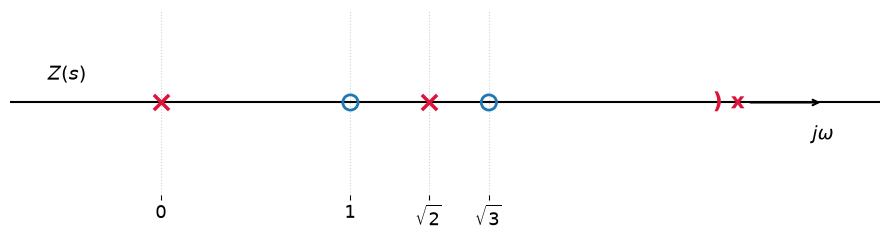

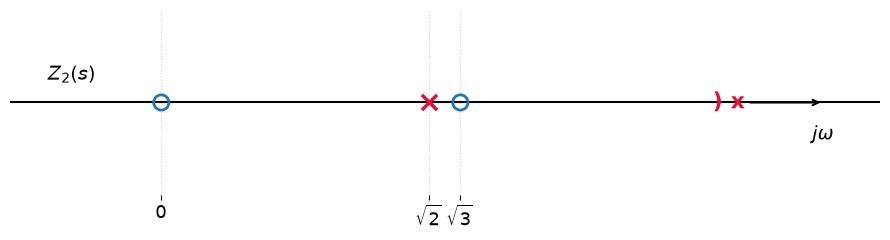

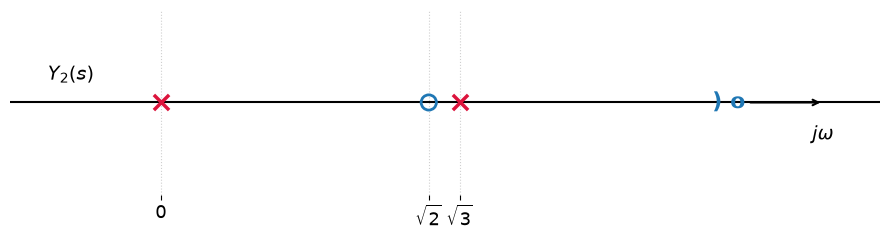

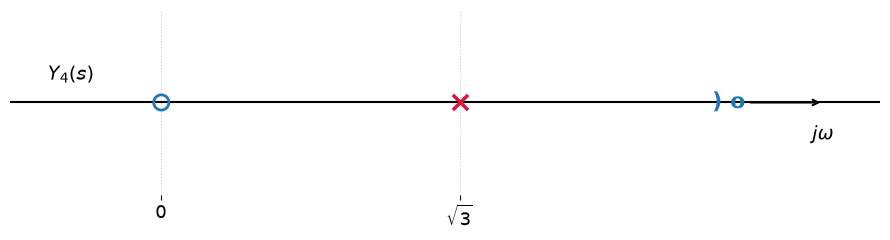

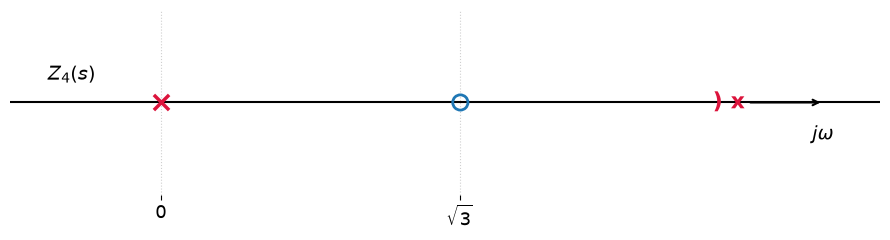

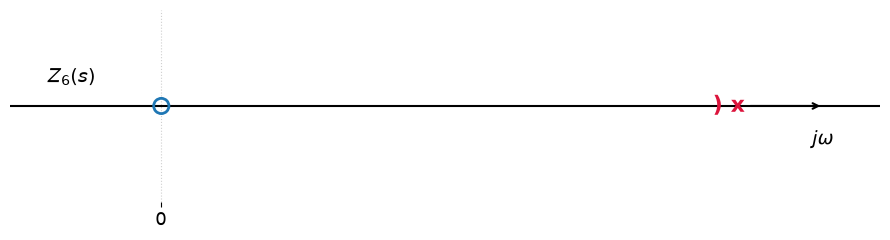

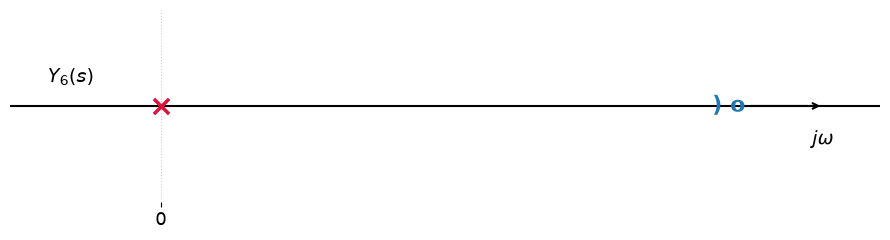

In [26]:
for nombre, expr in inmitancias:
    # 1. Cancelación y desarrollo algebraico seguro
    expr_simp = sp.cancel(sp.expand(expr))
    num_sp, den_sp = sp.fraction(expr_simp)
    
    # 2. Conversión a polinomios de SymPy asegurando el desarrollo de potencias
    num_poly = sp.Poly(sp.expand(num_sp), s)
    den_poly = sp.Poly(sp.expand(den_sp), s)
    
    # 3. Extracción de coeficientes numéricos
    num_coeffs = [float(c) for c in num_poly.all_coeffs()]
    den_coeffs = [float(c) for c in den_poly.all_coeffs()]
    
    # 4. Graficar diagrama 1D
    graficar_polos_ceros_1D(num_coeffs, den_coeffs, nombre_funcion=nombre)

Como podemos obesrvar los ceros se desplazan hacia la izquierda, donde el cero que esta despues del polo en 0 al realizar la remocion este pasa a ocupar su lugar.

### Verificacion

Procedemos a verificar nuestros componentes hallados.

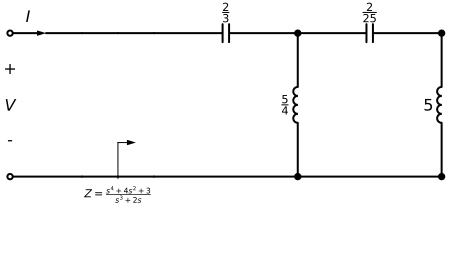

In [3]:
# Sea la siguiente función de excitación
FF = (s**4 + 4*s**2 + 3)/(s**3 + 2*s)

# Implementaremos FF mediante Cauer 1 o remociones continuas en infinito
koo, F_cauer_oo, rem = cauer_LC(FF, remover_en_inf=False)

# Tratamos a nuestra función inmitancia como una Z
dibujar_cauer_LC(koo, z_exc = FF)

### Análisis y Simulación en LTSpice de la Impedancia $Z(s)$

La función analizada es:
$$Z(s) = \frac{s^4 + 4s^2 + 3}{s(s^2 + 2)} = \frac{(s^2 + 1) \cdot (s^2 + 3)}{s \cdot (s^2 + 2)}$$


Primero analizamos sus frecuencias críticas (polos y ceros) para la simulación:

* **Polo en $s = 0$ (DC):** $f_{p0} = 0\text{ Hz}$
* **Primer Cero ($\omega_{z1} = 1\text{ rad/s}$):** $f_{z1} = \frac{1}{2\pi} \approx 159.15\text{ mHz}$
* **Primer Polo ($\omega_{p1} = \sqrt{2}\text{ rad/s}$):** $f_{p1} = \frac{\sqrt{2}}{2\pi} \approx 225.08\text{ mHz}$
* **Segundo Cero ($\omega_{z2} = \sqrt{3}\text{ rad/s}$):** $f_{z2} = \frac{\sqrt{3}}{2\pi} \approx 275.66\text{ mHz}$
* **Polo en $s \to \infty$:** $f \to \infty$

#### Grafica de LTSpice

**Visualizacion de los ceros**

# <img src="LTSpice_punto1_ceros_finitos.png" />

Podemos apreciar con los cursores que nos dan los cambios de fase en la singularidades (primer y segundo cero) que fueron calculadas anteriormente.

**Visualizacion de los polos**

# <img src="LTSpice_punto1_polos_finitos.png" />

Podemos apreciar con el cursor que nos da el cambio de fase en la singularidad (segundo polo) que fue calculado anteriormente.

#### Comportamiento en los Extremos ($s = 0$ y $s \to \infty$)

**Visualizacion de los polos**

# <img src="LTSpice_punto1_polo_infinito_DC.png" />

Polo en el origen ($s = 0$ / $1\text{ mHz}$):
   * *Magnitud:* A frecuencias muy bajas la impedancia crece hacia $+\infty\text{ dB}$ y va bajando con una pendiente de $-20\text{ dB/década}$. Esto refleja la presencia del término $\frac{1}{s}$ (dominio capacitivo puro del capacitor en serie $C_1$).
   * *Fase:* Se estabiliza de forma plana en $90^\circ$ (ya que la corriente adelanta a la tension), confirmando la naturaleza capacitiva pura.

Polo en el infinito ($s \to \infty$ / $100\text{ Hz}$):**
   * *Magnitud:* A frecuencias elevadas la impedancia crece indefinidamente hacia $+\infty\text{ dB}$ con una pendiente de $+20\text{ dB/década}$, debido al término dominante $s$ (dominio inductivo del inductor en serie $L_1$).
   * *Fase:* Se estabiliza de forma plana en $270^\circ$, confirmando el comportamiento inductivo puro.

#### Comportamiento de la grafica

Para cualquier red no disipativa (LC pura), la magnituda cae a 0 ($-\infty$) o cre a infinito ($+\infty$) debido a la interacción entre inductores y capacitores, por eso mismo la pendiente de la reactancia respecto a la frecuencia es estrictamente positiva:

$$\frac{dX(\omega)}{d\omega} > 0$$

Por eso, tras pasar por un cero (mínimo de impedancia), la magnitud siempre sube hacia el siguiente polo.
  
Para la fase, al no existir resistencias, la fase toma valores exclusivos de $\pm 90^\circ$. En cada frecuencia crítica ocurre un salto brusco de $180^\circ$, siendo para nuestro caso (por la referencia que toma el LTSpice) de $90^\circ a 270^\circ$:
  * **Al pasar por un Cero ($159\text{ mHz}$ y $275\text{ mHz}$):** La fase conmuta de capacitiva ($90^\circ$) a inductiva ($270^\circ$).
  * **Al pasar por un Polo ($225\text{ mHz}$):** La fase conmuta de inductiva ($270^\circ$) a capacitiva ($90^\circ$).

### Síntesis de la red

Sea la siguiente red:

# <img src="red_punto2_ts8.png" /> 

**Función de Inmitancia dada:**
$$Y(s) = \frac{s^5 + 18s^3 + 48s}{6s^4 + 42s^2 + 48}$$

Dado que la red comienza con un capacitor $C_1$ en serie (cuyo comportamiento para $s \to 0$ es un circuito abierto) seguido de un inductor $L_1$ en derivación, trabajamos con la función de **impedancia de entrada** $Z(s) = \frac{1}{Y(s)}$.

$$Z(s) = \frac{6s^4 + 42s^2 + 48}{s^5 + 18s^3 + 48s} = \frac{48 + 42s^2 + 6s^4}{48s + 18s^3 + s^5}$$

#### Método de Cauer II (Remoción en $s = 0$)

* Como comenzamos dividiendo la impedancia $Z(s)$, el primer cociente obtenido representa un **capacitor en serie** ($\frac{k}{s}$ con valor $C = \frac{1}{k}$).
* El residuo se invierte para transformarlo en una admitancia $Y(s)$, por lo que el siguiente cociente representa un **inductor en derivación** ($\frac{k}{s}$ con valor $L = \frac{1}{k}$).

**Primera División (Extracción de $C_1$)**

Dividimos los polinomios ordenados en potencias crecientes para extraer el primer término capacitivo en serie:

$$
\begin{array}{r|l}
48 + 42s^2 + 6s^4 & 48s + 18s^3 + s^5 \\
\hline & \mathbf{\frac{1}{s}} \\
48 + 42s^2 + 6s^4 \\
-(48 + 18s^2 + s^4) \\
\hline
\mathbf{24s^2 + 5s^4} & 
\end{array}
$$

El cociente $\frac{1}{s}$ indica un capacitor en serie de valor $C_1 = \frac{1}{1} = 1$.

**Segunda División (Extracción de $L_1$)**

Invertimos la función (pasamos a admitancia) dividiendo el divisor anterior entre el nuevo resto:

$$
\begin{array}{r|l}
48s + 18s^3 + s^5 & 24s^2 + 5s^4 \\
\hline & \mathbf{\frac{2}{s}} \\
48s + 18s^3 + s^5 \\
-(48s + 10s^3    ) \\
\hline
\mathbf{8s^3 + s^5} & 
\end{array}
$$

El cociente $\frac{2}{s}$ representa un inductor en derivación a masa de valor $L_1 = \frac{1}{2}$.

Para este punto tenemos nos queda la red (con los primeros 2 componentes removidos) donde intercambiamos de tal forma que inicia primero con el capacitor $C_3$ seguido del tanque $C_2, L_2$ de esta forma podemos seguir removiendo en DC y al llegar al tanque al remover el inductor $L_2$ nos quedara solo un capacitor ($C_2$) el cual lo podemos interpretar en serie o derivacio al ser el ultimo componente faltante, para seguir con el analisis que venimos haciendo, a este ultimo capacitor lo pensaremos como un capacitor en serie, asi todo se resuelve mediante remociones en DC.

**Tercera División (Extracción de $C_3$)**

Invertimos la función (pasamos a impedancia) dividiendo el divisor anterior entre el residuo remanente. Pensando la red remanente intercambiando el orden para colocar primero el capacitor $C_3$ en derivación:

$$
\begin{array}{r|l}
24s^2 + 5s^4 & 8s^3 + s^5 \\
\hline & \mathbf{\frac{3}{s}} \\
24s^2 + 5s^4 \\
-(24s^2 + 3s^4) \\
\hline
\mathbf{2s^4} & 
\end{array}
$$

El cociente $\frac{3}{s}$ representa el capacitor $C_3$ de valor $C_3 = \frac{1}{3}$.

**Cuarta División (Extracción de $L_2$)**

Invertimos la función (pasamos a admitancia) dividiendo el resto de la admitancia remanente entre el residuo obtenido para extraer el inductor $L_2$ del tanque resonante:

$$
\begin{array}{r|l}
8s^3 + s^5 & 2s^4 \\
\hline & \mathbf{\frac{4}{s}} \\
8s^3 + s^5 \\
-(8s^3) \\
\hline
\mathbf{s^5} & 
\end{array}
$$

El cociente $\frac{4}{s}$ representa el inductor $L_2$ de valor $L_2 = \frac{1}{4}$.

**Quinta División (Extracción de $C_2$)**

Invertimos nuevamente la función (pasamos a impedancia). El término sobrante representa el último componente faltante del tanque, interpretándolo como un capacitor $C_2$ en serie para completar el desarrollo por divisiones sucesivas:

$$
\begin{array}{r|l}
2s^4 & s^5 \\
\hline & \mathbf{\frac{2}{s}} \\
2s^4 \\
-(2s^4) \\
\hline
\mathbf{0} & 
\end{array}
$$

El cociente final $\frac{2}{s}$ da el valor del capacitor $C_2 = \frac{1}{2}\text{ F}$. Al llegar el resto a $0$, la síntesis queda completada exclusivamente mediante remociones en DC.

#### Valores de los componentes obtenidos

1. **$C_1 = 1\text{ F}$** (Capacitor en rama serie inicial)
2. **$L_1 = \frac{1}{2}$** (Inductor en rama derivación)
3. **$C_3 = \frac{1}{3}$** (Capacitor en rama derivación)
4. **$L_2 = \frac{1}{4}$** (Inductor del tanque paralelo en serie)
5. **$C_2 = \frac{1}{2}$** (Capacitor del tanque paralelo en serie)

### Verificacion por Python

Procedemos a verificar nuestro analisis usando Python.

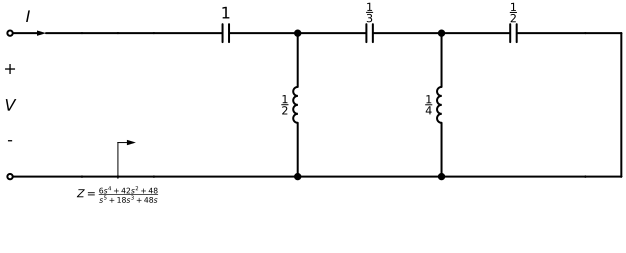

In [27]:
# Sea la siguiente función de excitación
FF = ( 6*s**4 + 42*s**2 + 48)/( s**5 + 18*s**3 + 48*s)

# Implementaremos FF mediante Cauer 1 o remociones continuas en infinito
koo, F_cauer_oo, rem = cauer_LC(FF, remover_en_inf=False)

# Tratamos a nuestra función inmitancia como una Z
dibujar_cauer_LC(koo, z_exc = FF)